1. Diseño y Construcción de una Red Convolucional Propia

1.1 Preprocesamiento de Datos

In [8]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import json

In [10]:
from pathlib import Path
import subprocess # https://docs.python.org/3/library/subprocess.html#subprocess.run

data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)
zip_path = data_dir / "raf-db-face-emotion-dataset.zip"
url = "https://www.kaggle.com/api/v1/datasets/download/zulkarnainsaurav/four-genre-movie-poster-images"

In [11]:
subprocess.run(["curl", "-L", "-o", str(zip_path), url], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
subprocess.run(["unzip", "-o", str(zip_path), "-d", str(data_dir)], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
zip_path.unlink(missing_ok=True)

In [16]:
import os
import shutil
import random
from pathlib import Path

data_dir = Path("data/four_genre_posters/four_genre_posters")
output_dir = Path("data/four_genre_posters_split")

splits = ["train", "validation", "test"]
split_ratio = [0.7, 0.2, 0.1]

for split in splits:
    for category in os.listdir(data_dir):
        Path(output_dir / split / category).mkdir(parents=True, exist_ok=True)

for category in os.listdir(data_dir):
    category_path = data_dir / category
    images = list(category_path.glob("*.jpg"))
    random.shuffle(images)

    n = len(images)
    train_end = int(0.7 * n)
    val_end = int(0.9 * n)

    split_sets = {
        "train": images[:train_end],
        "validation": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, imgs in split_sets.items():
        for img in imgs:
            shutil.copy(img, output_dir / split / category / img.name)

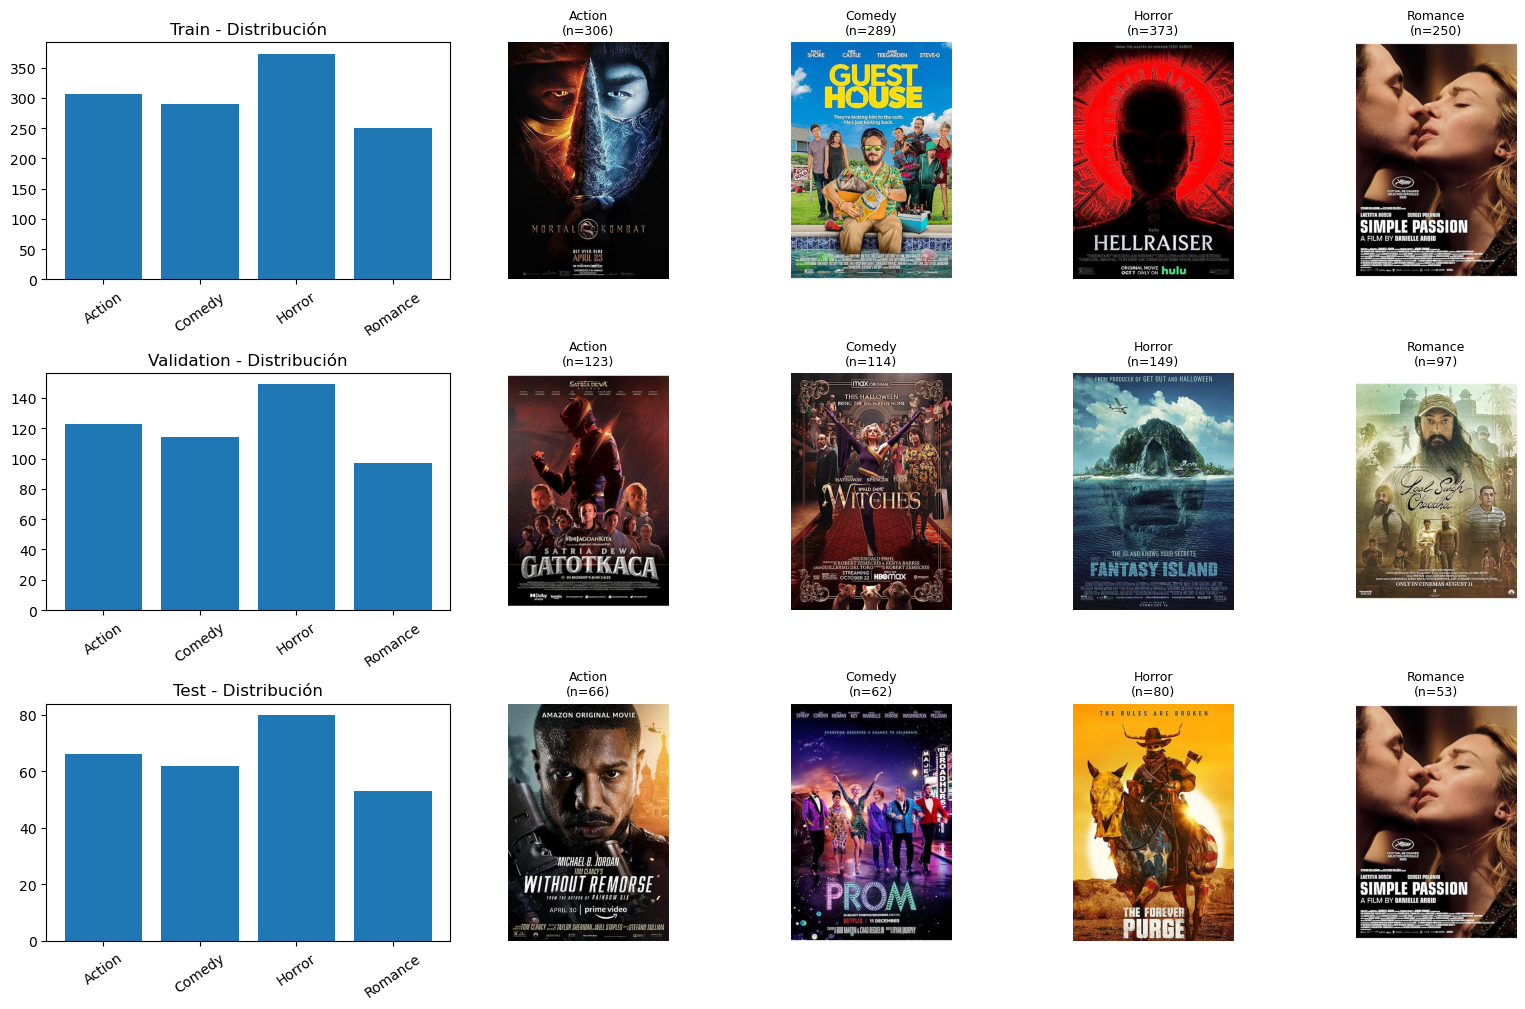

In [20]:
import matplotlib.pyplot as plt

train_path = Path("data/four_genre_posters_split/train")
test_path = Path("data/four_genre_posters_split/test")
validation_path = Path("data/four_genre_posters_split/validation")

splits = {
    "Train": train_path,
    "Validation": validation_path,
    "Test": test_path,
}

split_data = {}
max_classes = 0

for split_name, split_path in splits.items():
    class_dirs = sorted([d for d in Path(split_path).iterdir() if d.is_dir()])
    labels, counts, samples = [], [], []

    for d in class_dirs:
        imgs = sorted([p for p in d.rglob("*") if p.is_file() and p.suffix.lower() == ".jpg"])
        if imgs:
            labels.append(d.name)
            counts.append(len(imgs))
            samples.append(imgs[0])

    split_data[split_name] = (labels, counts, samples)
    max_classes = max(max_classes, len(labels))

fig = plt.figure(figsize=(3.2 * (max_classes + 1), 3.4 * len(splits)))
gs = fig.add_gridspec(len(splits), max_classes + 1, width_ratios=[1.4] + [1] * max_classes)

for r, (split_name, (labels, counts, samples)) in enumerate(split_data.items()):
    ax_bar = fig.add_subplot(gs[r, 0])
    ax_bar.bar(labels, counts)
    ax_bar.set_title(f"{split_name} - Distribución")
    ax_bar.tick_params(axis="x", rotation=35)

    for c in range(max_classes):
        ax_img = fig.add_subplot(gs[r, c + 1])
        if c < len(labels):
            ax_img.imshow(plt.imread(samples[c]))
            ax_img.set_title(f"{labels[c]}\n(n={counts[c]})", fontsize=9)
        ax_img.axis("off")

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

def build_dataframe(root_path):
    filepaths = [str(p) for p in root_path.rglob("*.jpg")]
    labels = [p.parent.name for p in map(Path, filepaths)]
    return pd.DataFrame({"filepath": filepaths, "label": labels})

train_df = build_dataframe(train_path)
test_df = build_dataframe(test_path)
validation_df = build_dataframe(validation_path)

def split_y(df, column):
    return df.drop(column, axis=1), df[column]

X_train, y_train = split_y(train_df, 'label')
X_val, y_val = split_y(validation_df, 'label')
X_test, y_test = split_y(test_df, 'label')

In [38]:
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)

eval_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

def make_flow(datagen, X_split, y_split, shuffle):
    df = X_split.copy()
    df["label"] = y_split.values
    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="filepath",
        y_col="label",
        target_size=(128, 128),
        color_mode="rgb",
        class_mode="categorical",
        classes=labels,
        batch_size=32,
        shuffle=shuffle,
        seed=42,
    )

train = make_flow(train_datagen, X_train, y_train, shuffle=True)
val = make_flow(eval_datagen, X_val, y_val, shuffle=False)
test = make_flow(eval_datagen, X_test, y_test, shuffle=False)

classes = np.unique(y_train.values)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = dict(zip(classes, weights))

Found 1218 validated image filenames belonging to 4 classes.
Found 483 validated image filenames belonging to 4 classes.
Found 261 validated image filenames belonging to 4 classes.


Arquitectura CNN

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Conv2D(32, (3, 3), padding="same", input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax"),
])

model.summary()

/opt/anaconda3/envs/notebook_1/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [40]:
# Compilar el modelo
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [41]:
# Funciones callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

In [42]:
# Entrenamiento
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("GPU is available. Training on GPU.")
    with tf.device('/GPU:0'):
      history = model.fit(
          train,
          validation_data=val,
          epochs=50,
          callbacks=callbacks,
          class_weight=class_weight,
      )
else:
    print("GPU is not available. Training on CPU.")
    history = model.fit(
        train,
        validation_data=val,
        epochs=50,
        callbacks=callbacks,
        class_weight=class_weight,
    )

test_loss, test_acc = model.evaluate(test)

GPU is not available. Training on CPU.
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.4384 - loss: 1.3308 - val_accuracy: 0.2008 - val_loss: 1.4302 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.4860 - loss: 1.1645 - val_accuracy: 0.2008 - val_loss: 1.6496 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.5074 - loss: 1.1471 - val_accuracy: 0.4182 - val_loss: 1.6698 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.5172 - loss: 1.1246 - val_accuracy: 0.3851 - val_loss: 1.7775 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.5205 - loss: 1.1054 - val_accuracy: 0.4017 - val_loss: 1.8163 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5381 - loss: 1.0959
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/st

Analisis del entrenamiento

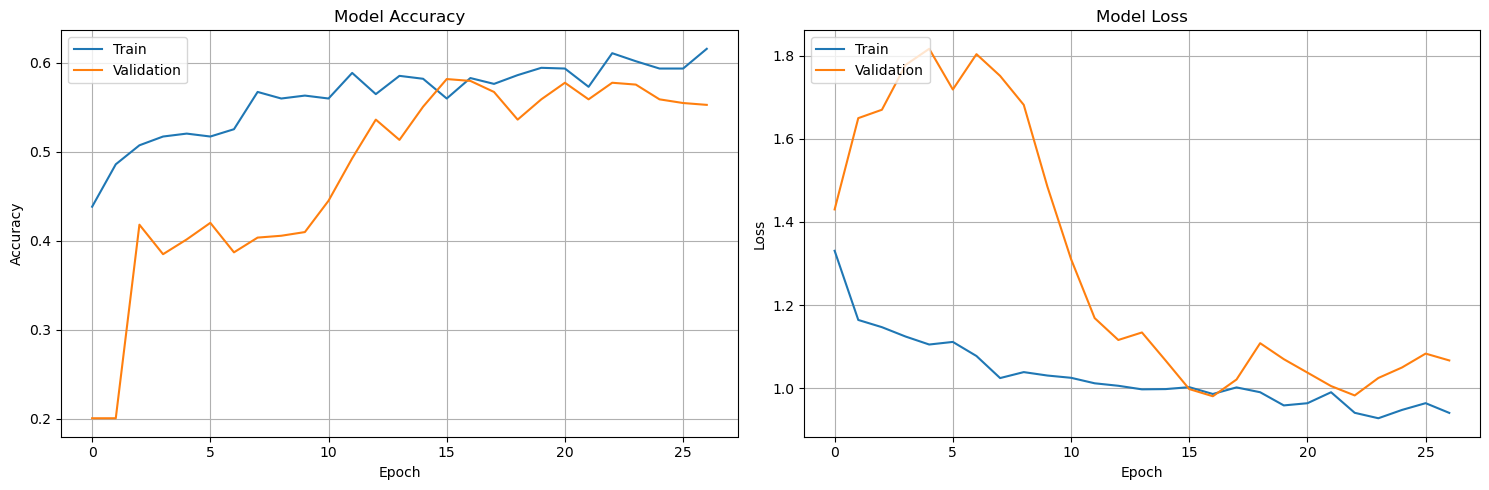

In [43]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


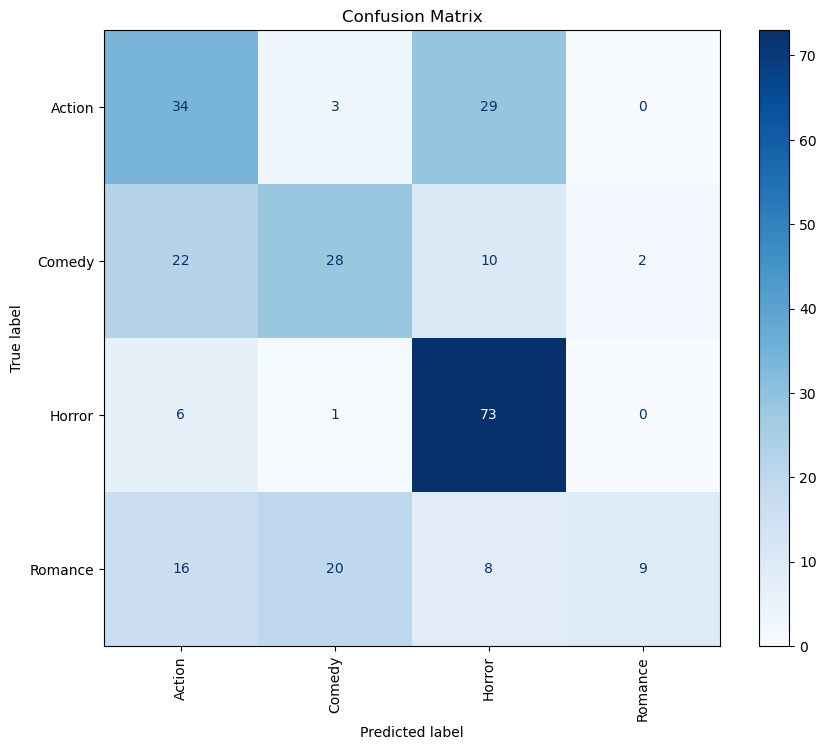

In [44]:
# Matriz de confusion

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_true = test.classes
y_pred_probabilities = model.predict(test)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [45]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Action     0.4359    0.5152    0.4722        66
      Comedy     0.5385    0.4516    0.4912        62
      Horror     0.6083    0.9125    0.7300        80
     Romance     0.8182    0.1698    0.2812        53

    accuracy                         0.5517       261
   macro avg     0.6002    0.5123    0.4937       261
weighted avg     0.5907    0.5517    0.5170       261



2. Experimentación y Optimización del Modelo

Ajuste de Arquitectura y Hiperparámetros

In [46]:
classes = np.unique(y_train.values)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train.values
)
class_weight = dict(zip(classes, weights))

alpha = 0.5
class_weight_scaled = {
    k: v**alpha for k, v in class_weight.items()
}

In [47]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential([
        layers.Conv2D(
            filters=hp.Choice('filters_1', [32, 64]),
            kernel_size=(3, 3),
            padding='same',
            activation='relu',
            input_shape=(128, 128, 3)
        ),
        layers.MaxPooling2D(2),

        layers.Conv2D(
            filters=hp.Choice('filters_2', [64, 128]),
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            units=hp.Choice('dense_units', [64, 128, 256]),
            activation='relu'
        ),

        layers.Dropout(hp.Float('dropout', 0.3, 0.6, step=0.1)),

        layers.Dense(4, activation='softmax')
    ])

    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [48]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=8,
    directory='tuner_dir',
    project_name='cnn_gen_tune'
)

/opt/anaconda3/envs/notebook_1/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
history = tuner.search(
    train,
    validation_data=val,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight_scaled
)

Trial 8 Complete [00h 01m 01s]
val_accuracy: 0.47204968333244324

Best val_accuracy So Far: 0.4761904776096344
Total elapsed time: 00h 06m 17s


In [52]:
best_model = tuner.get_best_models(1)[0]

history = best_model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_scaled
)
test_loss, test_acc = best_model.evaluate(test)

Epoch 1/50


/opt/anaconda3/envs/notebook_1/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.4614 - loss: 1.1865 - val_accuracy: 0.4783 - val_loss: 1.1511 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.4984 - loss: 1.1631 - val_accuracy: 0.4700 - val_loss: 1.1596 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.4688 - loss: 1.1769 - val_accuracy: 0.4658 - val_loss: 1.1574 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.4828 - loss: 1.1648 - val_accuracy: 0.4638 - val_loss: 1.1485 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5020 - loss: 1.1333
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.4967 - loss: 1.1510 - val_accuracy: 0.4948 - val_loss: 1.1309 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.4943 - loss: 1.1327 - val_accuracy

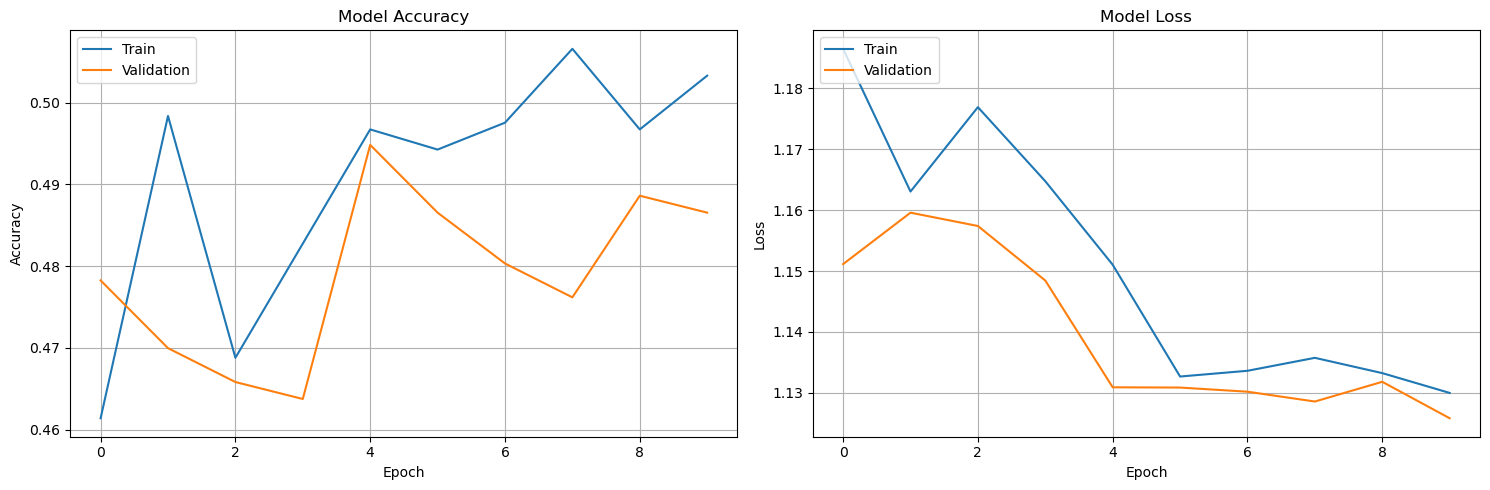

In [53]:
plot_training_history(history)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


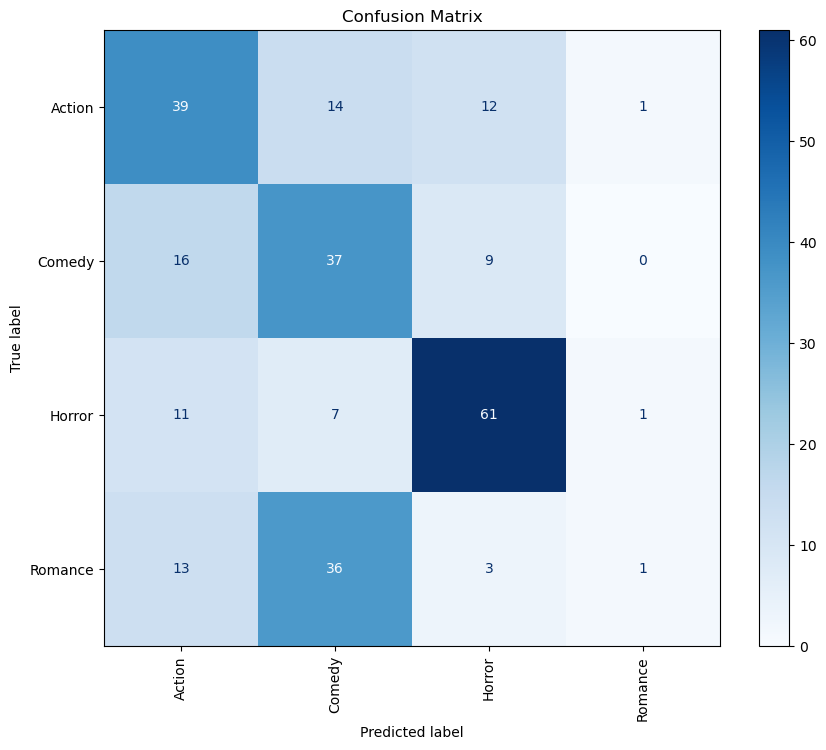

In [55]:
# Matriz de confusión
y_true = test.classes
y_pred_probabilities = best_model.predict(test)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [56]:
print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Action     0.4937    0.5909    0.5379        66
      Comedy     0.3936    0.5968    0.4744        62
      Horror     0.7176    0.7625    0.7394        80
     Romance     0.3333    0.0189    0.0357        53

    accuracy                         0.5287       261
   macro avg     0.4846    0.4923    0.4468       261
weighted avg     0.5060    0.5287    0.4826       261

